# Graph Neural Network Training

This notebook trains a Linear-Time GNN (LTGNN) for venue recommendations.

Features:
- Heterogeneous graph with user, venue, topic, and region nodes
- Fixed-point iteration (avoids over-smoothing)
- EVR sampling for scalability
- gBCE loss to reduce overconfidence

In [1]:
import os
import sys

# Accurate CUDA error reporting (shows real line, not async garbage)
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
# Prevent CUDA memory fragmentation on Windows
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch

from src.config import get_config, MODEL_DIR
from src.config.settings import  PROCESSED_DATA_DIR, CHECKPOINT_DIR
from src.models.gnn import (
    HeteroGraphBuilder,
    LTGNN,
    GNNTrainer,
    TrainTestSplit,
    gBCELoss,
)
from src.utils.helpers import set_seed, get_device

# Setup
set_seed(42)
config = get_config()
device = get_device('cuda')  # or 'mps', 'cpu'
print(f"Using device: {device}")

Using device: cuda


## 1. Load Data and Embeddings

In [2]:
# Load interaction data
train_reviews = pd.read_parquet(PROCESSED_DATA_DIR / 'train_reviews.parquet')
val_reviews = pd.read_parquet(PROCESSED_DATA_DIR / 'val_reviews.parquet')

print(f"Train interactions: {len(train_reviews)}")
print(f"Val interactions: {len(val_reviews)}")
print(f"Unique users: {train_reviews['user_id'].nunique()}")
print(f"Unique venues: {train_reviews['business_id'].nunique()}")

Train interactions: 4659
Val interactions: 583
Unique users: 4539
Unique venues: 1810


In [3]:
# Load user MBTI profiles (from Phase 2)
user_profiles_path = PROCESSED_DATA_DIR / 'user_mbti_profiles.parquet'
user_emb_path = PROCESSED_DATA_DIR / 'user_mbti_embeddings.npy'

if user_profiles_path.exists():
    user_profiles = pd.read_parquet(user_profiles_path)
    print(f"Loaded {len(user_profiles)} user profiles")
else:
    # Create from train data
    user_profiles = pd.DataFrame({'user_id': train_reviews['user_id'].unique()})
    print(f"Created {len(user_profiles)} user profiles from train data")

if user_emb_path.exists():
    user_embeddings = np.load(user_emb_path)
    print(f"User embeddings shape: {user_embeddings.shape}")
else:
    # Random initialization
    EMBED_DIM = 64
    user_embeddings = np.random.randn(len(user_profiles), EMBED_DIM).astype(np.float32) * 0.1
    print(f"Created random user embeddings: {user_embeddings.shape}")

Created 4539 user profiles from train data
Created random user embeddings: (4539, 64)


In [4]:
# Load venue topics and embeddings (from Phase 3)
venue_topics_path = MODEL_DIR / 'bertopic' / 'venue_topics.parquet'
venue_emb_path = MODEL_DIR / 'bertopic' / 'venue_embeddings.npy'

if venue_topics_path.exists():
    venue_topics = pd.read_parquet(venue_topics_path)
    print(f"Loaded {len(venue_topics)} venue topics")
else:
    # Create from train data
    venue_topics = pd.DataFrame({
        'venue_id': train_reviews['business_id'].unique(),
        'topic': 0
    })
    print(f"Created {len(venue_topics)} venue records from train data")

if venue_emb_path.exists():
    venue_embeddings = np.load(venue_emb_path)
    print(f"Venue embeddings shape: {venue_embeddings.shape}")
else:
    # Random initialization
    EMBED_DIM = 64
    venue_embeddings = np.random.randn(len(venue_topics), EMBED_DIM).astype(np.float32) * 0.1
    print(f"Created random venue embeddings: {venue_embeddings.shape}")

Loaded 85814 venue topics
Venue embeddings shape: (1000, 384)


## 2. Build Heterogeneous Graph

In [5]:
# Initialize graph builder
builder = HeteroGraphBuilder(device=device)

# Add user nodes
builder.add_user_nodes(
    user_profiles['user_id'].tolist(),
    user_embeddings,
)

# Add venue nodes
builder.add_venue_nodes(
    venue_topics['venue_id'].tolist(),
    venue_embeddings,
)

In [6]:
# Add user-venue edges from training data
builder.add_user_venue_edges(
    train_reviews['user_id'].tolist(),
    train_reviews['business_id'].tolist(),
    train_reviews['stars'].tolist() if 'stars' in train_reviews.columns else None,
)

In [7]:
# Graph statistics
stats = builder.get_statistics()
print("Graph Statistics:")
print(f"  Node types: {stats['node_types']}")
print(f"  Edge types: {stats['edge_types']}")
print("\nNodes:")
for node_type, info in stats['nodes'].items():
    print(f"  {node_type}: {info['count']} nodes, {info['feature_dim']} features")
print("\nEdges:")
for edge_type, info in stats['edges'].items():
    print(f"  {edge_type}: {info['count']} edges")

Graph Statistics:
  Node types: 2
  Edge types: 2

Nodes:
  user: 4539 nodes, 64 features
  venue: 85814 nodes, 384 features

Edges:
  ('user', 'visits', 'venue'): 4643 edges
  ('venue', 'rev_visits', 'user'): 4643 edges


In [8]:
# Get edge indices
train_edge_index = builder.edges[('user', 'visits', 'venue')].edge_index

# Create validation edges (vectorized)
user_node = builder.nodes['user']
venue_node = builder.nodes['venue']

val_user_idx = np.array([
    user_node.id_to_idx.get(uid, -1)
    for uid in val_reviews['user_id'].values
])
val_venue_idx = np.array([
    venue_node.id_to_idx.get(vid, -1)
    for vid in val_reviews['business_id'].values
])
valid = (val_user_idx >= 0) & (val_venue_idx >= 0)
val_edge_index = torch.tensor(
    [val_user_idx[valid], val_venue_idx[valid]], dtype=torch.long
)

print(f"Train edges: {train_edge_index.size(1)}")
print(f"Val edges: {val_edge_index.size(1)}")
print(f"  (skipped {(~valid).sum()} val interactions with unknown user/venue)")

Train edges: 4643
Val edges: 31
  (skipped 552 val interactions with unknown user/venue)


C:\Users\ewenl\AppData\Local\Temp\ipykernel_82816\1297519427.py:17: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  val_edge_index = torch.tensor(


## 3. Create LTGNN Model

In [ ]:
# Model hyperparameters
HIDDEN_DIM = 128
EMBEDDING_DIM = 64
NUM_ITERATIONS = 5  # 5 is sufficient, 10 is overkill
DROPOUT = 0.2

# Create model
model = LTGNN(
    user_input_dim=user_embeddings.shape[1],
    venue_input_dim=venue_embeddings.shape[1],
    hidden_dim=HIDDEN_DIM,
    embedding_dim=EMBEDDING_DIM,
    num_iterations=NUM_ITERATIONS,
    dropout=DROPOUT,
)

# Count parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")
print(model)

Model parameters: 115,532
LTGNN(
  (user_projection): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (venue_projection): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (gnn): FixedPointLayer(
    (conv): LightGCNConv()
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (output_projection): Linear(in_features=128, out_features=64, bias=True)
  (link_predictor): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 4. Train the Model

In [10]:
# Configure training
config.gnn.num_epochs = 15
config.gnn.batch_size = 4096
config.gnn.learning_rate = 0.001

# Convert to tensors
user_features = torch.tensor(user_embeddings, dtype=torch.float32)
venue_features = torch.tensor(venue_embeddings, dtype=torch.float32)

# Create trainer
trainer = GNNTrainer(
    model=model,
    user_features=user_features,
    venue_features=venue_features,
    train_edge_index=train_edge_index,
    val_edge_index=val_edge_index,
    config=config.gnn,
    device=device,
    use_gbce=True,  # Use gBCE loss
    gbce_t=0.8,     # Temperature
)

c:\Users\ewenl\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\module.py:1326: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10/cuda/CUDAAllocatorConfig.h:28.)
  return t.to(
train edges: 4596/4643 dropped (max_user=4538 vs num_users=4539, max_venue=85772 vs num_venues=1000)
val edges: 30/31 dropped (max_user=4406 vs num_users=4539, max_venue=84242 vs num_venues=1000)


In [21]:
# Train
history = trainer.train()

Epoch 1/15: 100%|██████████| 1/1 [00:00<00:00, 41.86it/s, loss=1.2189]


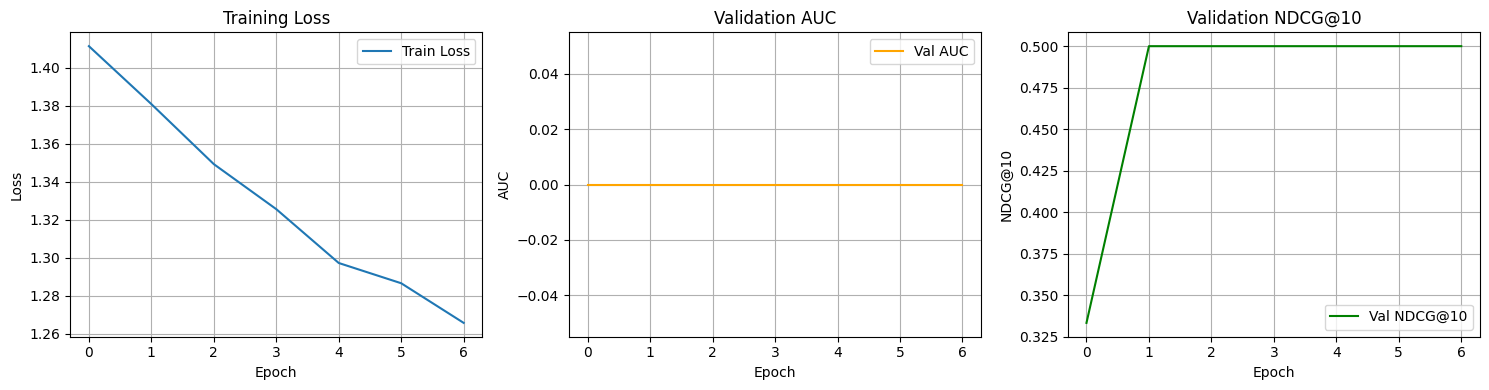


Best NDCG@10: 0.5000


In [12]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
train_loss = [h['loss'] for h in history['train_history']]
axes[0].plot(train_loss, label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True)

# AUC
val_auc = [h['auc'] for h in history['val_history']]
axes[1].plot(val_auc, label='Val AUC', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('Validation AUC')
axes[1].legend()
axes[1].grid(True)

# NDCG@10
val_ndcg = [h['ndcg_at_10'] for h in history['val_history']]
axes[2].plot(val_ndcg, label='Val NDCG@10', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('NDCG@10')
axes[2].set_title('Validation NDCG@10')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"\nBest NDCG@10: {history['best_metric']:.4f}")

## 5. Extract Embeddings

In [13]:
# Get final embeddings
user_emb, venue_emb = trainer.get_embeddings()

print(f"User embeddings: {user_emb.shape}")
print(f"Venue embeddings: {venue_emb.shape}")

User embeddings: torch.Size([4539, 64])
Venue embeddings: torch.Size([1000, 64])


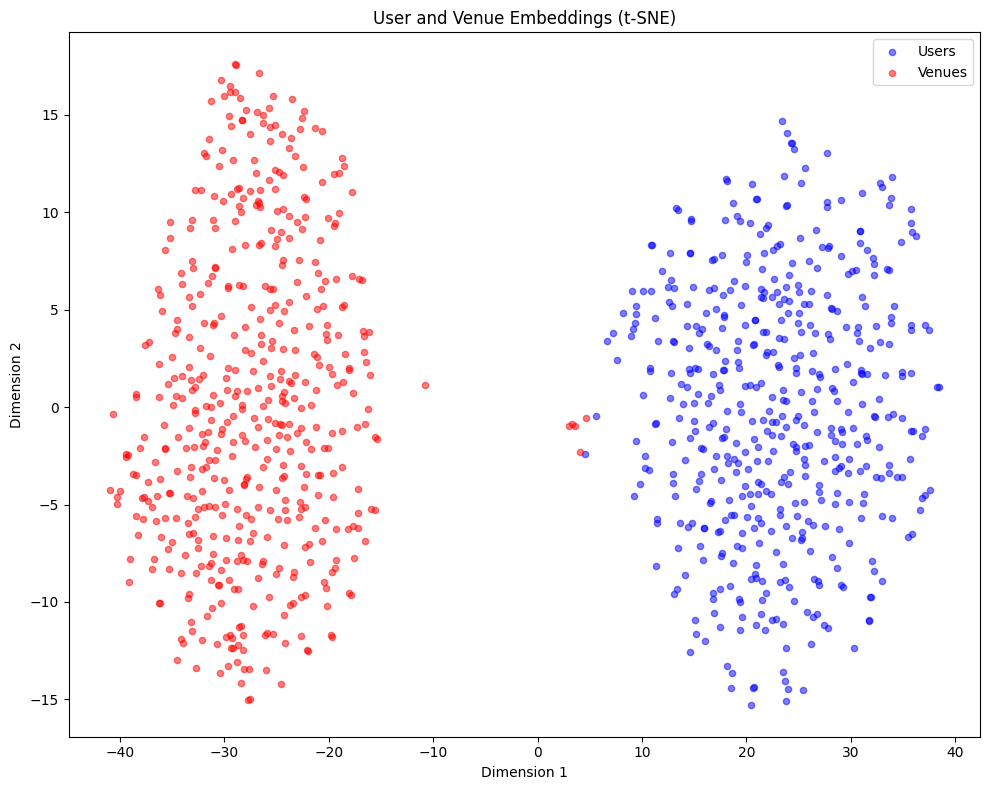

In [14]:
# Visualize embedding space with t-SNE
from sklearn.manifold import TSNE

# Sample for visualization
n_sample = 500
user_sample = user_emb[:n_sample].cpu().numpy()
venue_sample = venue_emb[:n_sample].cpu().numpy()

# Combine and reduce
combined = np.vstack([user_sample, venue_sample])
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced = tsne.fit_transform(combined)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(
    reduced[:n_sample, 0], reduced[:n_sample, 1],
    c='blue', alpha=0.5, label='Users', s=20
)
plt.scatter(
    reduced[n_sample:, 0], reduced[n_sample:, 1],
    c='red', alpha=0.5, label='Venues', s=20
)
plt.legend()
plt.title('User and Venue Embeddings (t-SNE)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.tight_layout()
plt.show()

## 6. Test Recommendations

In [15]:
# Get recommendations for a sample user
sample_user_idx = 0
sample_user_id = user_profiles.iloc[sample_user_idx]['user_id']

rec_indices, rec_scores = trainer.recommend_for_user(
    user_idx=sample_user_idx,
    k=10,
    exclude_visited=True,
)

print(f"Recommendations for user {sample_user_id}:")
print(f"{'Rank':<6} {'Venue ID':<20} {'Score':<10}")
print("-" * 40)

for rank, (idx, score) in enumerate(zip(rec_indices, rec_scores), 1):
    venue_id = venue_topics.iloc[idx]['venue_id']
    print(f"{rank:<6} {venue_id:<20} {score:.4f}")

Recommendations for user mPP4DcMrv8xSTvy73dwDTA:
Rank   Venue ID             Score     
----------------------------------------
1      -OIUunijjcq_ZzyyQhPPFQ 0.6850
2      -M21d-vRVRaTyVywy8x-Ag 0.6370
3      -d8B04ueyxADRutlcHYewQ 0.6207
4      -If0ps0QhOLCYVWQWs9RYg 0.6148
5      -2ke_JDOpgTZWqirMFjZcw 0.6041
6      -hVMfjPPEsSnga_gnYJx2w 0.5976
7      -3AooxIkg38UyUdlz5oXdw 0.5933
8      -K_FDDqmOt6hJLTOPgpnlA 0.5914
9      -V0vIgo6196MDn_x3ZaYmA 0.5901
10     -Fka99c-tJ-epWYNIobqyQ 0.5896


In [16]:
# Check user's actual visits
user_visits = train_reviews[train_reviews['user_id'] == sample_user_id]
print(f"\nUser's actual visits ({len(user_visits)} total):")
print(user_visits[['business_id', 'stars']].head(10))


User's actual visits (1 total):
              business_id  stars
0  2bl6G1zgXUHbMGwEocqMSg    5.0


## 7. Save Results

In [17]:
# Save embeddings
output_dir = MODEL_DIR / 'gnn'
output_dir.mkdir(parents=True, exist_ok=True)

np.save(output_dir / 'user_gnn_embeddings.npy', user_emb.cpu().numpy())
np.save(output_dir / 'venue_gnn_embeddings.npy', venue_emb.cpu().numpy())

# Save graph
builder.save(output_dir / 'graph')

print(f"Saved embeddings and graph to {output_dir}")

c:\Users\ewenl\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  import torch_geometric.typing
c:\Users\ewenl\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  import torch_geometric.typing
c:\Users\ewenl\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  import torch_geometric.typing


Saved embeddings and graph to c:\Users\ewenl\draft-koko\notebooks\..\models\gnn


In [18]:
# Save ID mappings for later use
id_mappings = {
    'user_ids': user_profiles['user_id'].tolist(),
    'venue_ids': venue_topics['venue_id'].tolist(),
}

import json
with open(output_dir / 'id_mappings.json', 'w') as f:
    json.dump(id_mappings, f)

print("Saved ID mappings")

Saved ID mappings


## Summary

We've trained a Linear-Time GNN that:
1. Uses fixed-point iteration (avoids over-smoothing)
2. Employs gBCE loss (reduces overconfidence)
3. Generates user and venue embeddings for recommendations

Next step: **Phase 5** - Combine GNN embeddings with XGBoost for final hybrid recommendations.